# Exercise 7

In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import math
import time

## Part 1

Number of points: 20
Initial route: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
Shuffled route: [19  3 10 15  9 18 16 14 17 11  6  2 13  8  7  4  5 12  0  1]
Best route:
[12 13  1  5 11  3 18 19  6 17  4 14  9  7 15 16  8  0 10  2]
Best cost:
4.6452004446438915


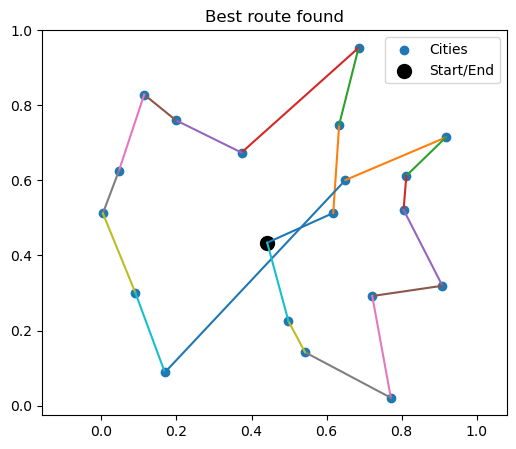

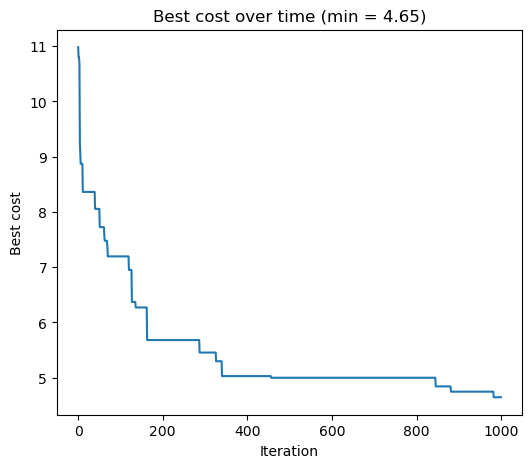

In [2]:

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(10)

def route_cost(route, points):
    """
    Compute total distance of a closed route (Euclidean).
    """
    total = 0
    n = len(route)  # number of cities

    for i in range(n):
        current = route[i]
        nxt = route[(i + 1) % n]
        total += np.linalg.norm(points[current] - points[nxt])

    return total


def propose_swap(route):
    """
    Create a new route by swapping two random cities.
    """
    new_route = route.copy()

    i, j = np.random.choice(len(route), size=2, replace=False)
    new_route[i], new_route[j] = new_route[j], new_route[i]

    return new_route


def temperature(k):
    """
    Cooling schedule.
    """
    return 1 / np.sqrt(1 + k)


def simulated_annealing(points, num_iterations):
    """
    Simulated annealing for the travelling salesman problem.
    """
    print("Number of points:", len(points))
    n = len(points)

    # Start with a random route
    current_route = np.arange(n)
    print("Initial route:", current_route)
    np.random.shuffle(current_route)
    print("Shuffled route:", current_route)

    current_cost = route_cost(current_route, points)

    # Best solution found so far
    best_route = current_route.copy()
    best_cost = current_cost

    costs = []

    for k in range(num_iterations):
        T = temperature(k)

        # Propose new route by swapping two cities
        candidate_route = propose_swap(current_route)
        candidate_cost = route_cost(candidate_route, points)

        delta = candidate_cost - current_cost

        # Accept if better
        if delta <= 0:
            current_route = candidate_route
            current_cost = candidate_cost
        else:
            # Accept with some probability
            prob = np.exp(-delta / T)
            if np.random.rand() < prob:
                current_route = candidate_route
                current_cost = candidate_cost

        # Update best solution
        if current_cost < best_cost:
            best_route = current_route.copy()
            best_cost = current_cost

        costs.append(best_cost)

    return best_route, best_cost, costs


# Number of cities
n = 20

# Choose distribution of points
# point_type = "unit_circle"
point_type = "unit_square"

if point_type == "unit_square":
    points = np.random.rand(n, 2)

elif point_type == "unit_circle":
    theta = np.linspace(0, 2 * np.pi, n, endpoint=False)
    points = np.column_stack((np.cos(theta), np.sin(theta)))


# Run simulated annealing
best_route, best_cost, costs = simulated_annealing(
    points,
    num_iterations=1000
)

print("Best route:")
print(best_route)

print("Best cost:")
print(best_cost)


# --- Plot best route ---
plt.figure(figsize=(6, 5))

for i in range(len(best_route)):
    p1 = points[best_route[i]]
    p2 = points[best_route[(i + 1) % len(best_route)]]
    plt.plot([p1[0], p2[0]], [p1[1], p2[1]])

plt.scatter(points[:, 0], points[:, 1], label="Cities")
plt.scatter(
    points[best_route[0], 0],
    points[best_route[0], 1],
    color="black",
    s=100,
    label="Start/End"
)

plt.axis("equal")
plt.title("Best route found")
plt.legend()
plt.show()


# --- Plot cost over time ---
plt.figure(figsize=(6, 5))
plt.plot(costs)
plt.xlabel("Iteration")
plt.ylabel("Best cost")
plt.title(f"Best cost over time (min = {best_cost:.2f})")
plt.show()

## Part 2

In [ ]:
# Exercise 7 - Part 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(10)

def route_cost(route, cost_matrix):
    """
    Compute total route cost using the cost matrix.
    The route returns to the starting city.
    """
    total = 0
    n = len(route)

    for i in range(n):
        current = route[i]
        nxt = route[(i + 1) % n]  # wrap around to start
        total += cost_matrix[current, nxt]

    return total


def propose_swap(route):
    """
    Create a new route by swapping two random cities.
    """
    new_route = route.copy()  # keep original unchanged

    i, j = np.random.choice(len(route), size=2, replace=False)
    new_route[i], new_route[j] = new_route[j], new_route[i]

    return new_route


def proposal_2opt(route):
    """
    Swap two neighboring cities at a random position.
    Example: [0,1,2,3] -> [0,2,1,3]
    """
    new_route = route.copy()

    i = np.random.randint(1, len(route) - 1)
    new_route[i - 1], new_route[i] = new_route[i], new_route[i - 1]

    return new_route


def temperature(k):
    """
    Cooling schedule.
    """
    return 1 / np.sqrt(1 + k)
    # other options:
    # return 1 / np.log(2 + k)
    # return np.exp(-k / 1000)


def simulated_annealing(cost_matrix, num_iterations):
    n = cost_matrix.shape[0]  # number of cities

    # Start with a random route
    current_route = np.arange(n)
    np.random.shuffle(current_route)

    current_cost = route_cost(current_route, cost_matrix)

    best_route = current_route.copy()
    best_cost = current_cost

    costs = []

    for k in range(num_iterations):
        T = temperature(k)

        # Propose new route
        candidate_route = propose_swap(current_route)
        # candidate_route = proposal_2opt(current_route)

        candidate_cost = route_cost(candidate_route, cost_matrix)
        delta = candidate_cost - current_cost

        # Accept if better
        if delta <= 0:
            current_route = candidate_route
            current_cost = candidate_cost
        else:
            # Accept with some probability
            prob = np.exp(-delta / T)
            if np.random.rand() < prob:
                current_route = candidate_route
                current_cost = candidate_cost

        # Update best solution
        if current_cost < best_cost:
            best_route = current_route.copy()
            best_cost = current_cost

        costs.append(best_cost)

    return best_route, best_cost, costs


# --- Load cost matrix ---
cost_matrix = pd.read_csv("cost.csv", header=None).values

best_route, best_cost, costs = simulated_annealing(
    cost_matrix,
    num_iterations=1000
)

print("Best route:")
print(best_route)

print("Best cost:")
print(best_cost)


# --- Plot best cost over time ---
plt.plot(costs)
plt.xlabel("Iteration")
plt.ylabel("Best cost")
plt.title(f"Best cost over time (min = {best_cost:.2f})")
plt.show()


# --- Plot cooling schedule ---
plt.plot([temperature(k) for k in range(1000)])
plt.xlabel("Iteration")
plt.ylabel("Temperature")
plt.title("Cooling schedule")
plt.show()